# Paso 4: EDA
https://github.com/PlayingNumbers/ds_salary_proj/blob/data_eda/data_cleaning.ipynb

In [1]:
#### Importacion de modulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#### Leyendo los datos
df = pd.read_csv('datos_limpios.csv')

### Separando datos en cuantitativos y cualitativos

In [3]:
#### Prevista total de los datos
df.head()

### Separando las columnas: cualitativa (categorical) y cuantitativa
    # Cualitativa: 'Industry', 'Sector', 'Revenue', 'titulo', 'senioridad', 'compania', 'estado', 'tamano', 'org', 'num_comps'
        # Binario: 'cada_hora', 'empleador', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'HQ', 
    # Cuantitativa: 'Rating', 'sueldo_min', 'sueldo_max', 'sueldo_promedio', 'len_desc', 'ano'

,Rating,Industry,Sector,Revenue,cada_hora,empleador,sueldo_min,sueldo_max,sueldo_promedio,titulo,...,aws_yn,excel_yn,len_desc,compania,estado,HQ,tamano,ano,org,num_comps
0,3.8,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),0,0,53,91,72.0,cientifico de datos,...,0,1,2536,Tecolote Research,NM,0,501-1000,47,privado,-1
1,3.4,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),0,0,63,112,87.5,cientifico de datos,...,0,0,4783,University of Maryland Medical System,MD,0,10000+,36,na,-1
2,4.8,Security Services,Business Services,$100 to $500 million (USD),0,0,80,90,85.0,cientifico de datos,...,0,1,3461,KnowBe4,FL,1,501-1000,10,privado,-1
3,3.8,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),0,0,56,97,76.5,cientifico de datos,...,0,0,3883,PNNL,WA,1,1001-5000,55,gubernamental,3
4,2.9,Advertising & Marketing,Business Services,Unknown / Non-Applicable,0,0,86,143,114.5,cientifico de datos,...,0,1,2728,Affinity Solutions,NY,1,51-200,22,privado,3


### Estadistica basica para varaibles cuantitativos

In [4]:
#### Viendo estadisticos basicos para varaibles cuantitativas
df[['Rating', 'sueldo_min', 'sueldo_max', 'sueldo_promedio', 'len_desc', 'ano']].describe()

,Rating,sueldo_min,sueldo_max,sueldo_promedio,len_desc,ano
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,74.719677,128.149596,101.434636,3869.545822,46.591644
std,0.801210,30.980593,45.220324,37.546122,1521.495868,53.778815
min,-1.000000,15.000000,16.000000,15.500000,407.000000,-1.000000
25%,3.300000,52.000000,96.000000,73.500000,2801.000000,11.000000
50%,3.700000,69.500000,124.000000,97.500000,3731.000000,24.000000
75%,4.000000,91.000000,155.000000,122.500000,4740.000000,59.000000
max,5.000000,202.000000,306.000000,254.000000,10051.000000,276.000000


### HIstogramas

<Axes: >

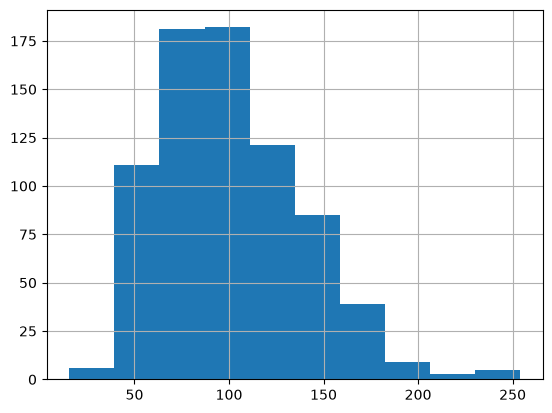

In [5]:
#### Histograma VD
df['sueldo_promedio'].hist()

<Axes: >

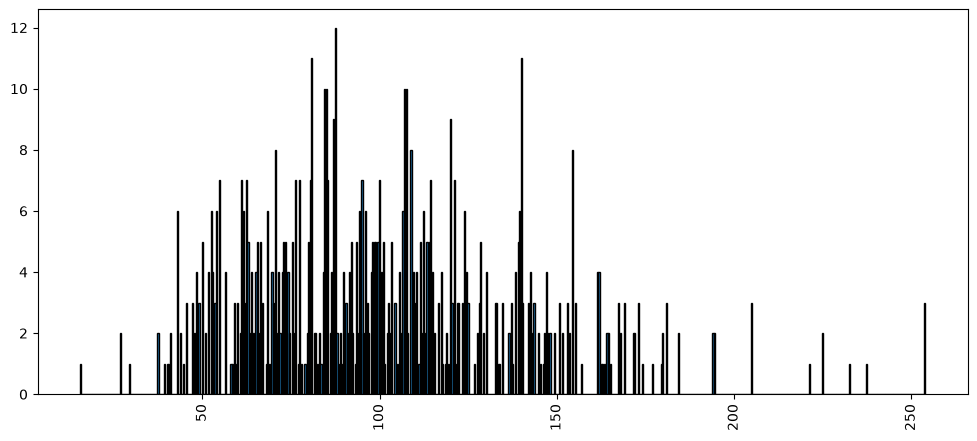

In [12]:
#### Histogramas
cualitativa= ['Industry', 'Sector', 'Revenue', 'titulo', 'senioridad', 'compania', 'estado', 'tamano', 'org']
binario= ['cada_hora', 'empleador', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'HQ' ]
cuantitativa= ['Rating', 'sueldo_min', 'sueldo_max', 'sueldo_promedio', 'len_desc', 'ano', 'num_comps']

### Seleccion
# seleccion = cualitativa[-2]
# seleccion = binario[-1]
seleccion = cuantitativa[3]
df[seleccion].hist(figsize=(12,5),xrot=90, grid = False, edgecolor='black', bins = len(df[seleccion].to_list()))
    # Se cambia el numero de bins para que cada valor tenga su bin

### Boxplots

In [7]:
#### Standarizacion de variables cuatitativas
df_std = (df[cuantitativa] - df[cuantitativa].mean())/df[cuantitativa].std()
df_std

,Rating,sueldo_min,sueldo_max,sueldo_promedio,len_desc,ano,num_comps
0,0.226073,-0.701074,-0.821524,-0.783959,-0.876470,0.007593,-0.770842
1,-0.273172,-0.378291,-0.357131,-0.371134,0.600366,-0.196948,-0.770842
2,1.474185,0.170440,-0.843638,-0.437719,-0.268516,-0.680410,-0.770842
3,0.226073,-0.604239,-0.688841,-0.664107,0.008843,0.156351,1.379402
4,-0.897228,0.364109,0.328401,0.347982,-0.750279,-0.457274,1.379402
...,...,...,...,...,...,...,...
737,0.350884,-0.539682,-0.379245,-0.451036,1.506711,2.666633,1.379402
738,0.974940,-0.087786,0.107262,0.028375,1.485679,-0.606031,1.379402
739,-1.271661,-0.604239,-0.821524,-0.744009,-0.520242,-0.196948,-0.770842
740,-0.522794,0.654614,0.704338,0.694223,-1.464050,-0.884952,-0.770842


<Axes: >

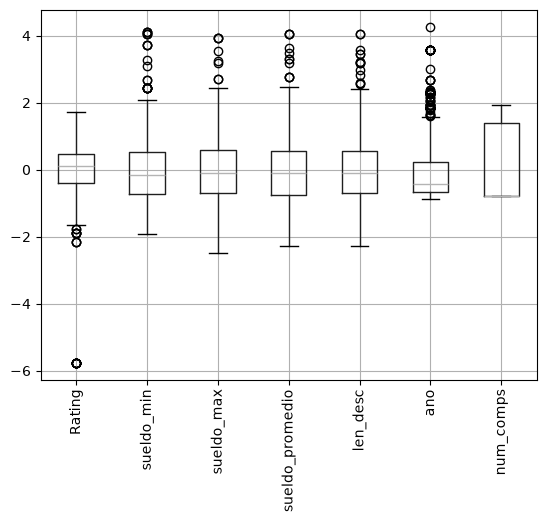

In [8]:
##### visualizacndo boxplots
df_std.boxplot(column=cuantitativa, rot=90)

<Axes: >

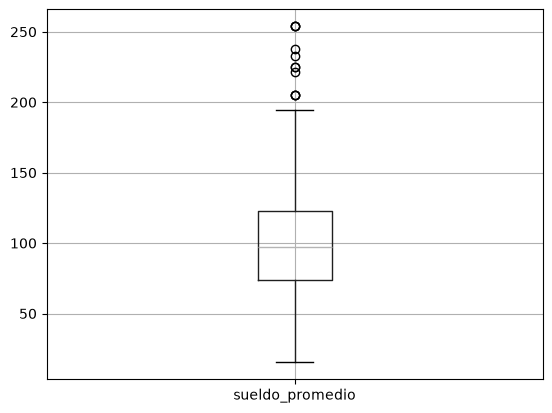

In [9]:
df.boxplot(column='sueldo_promedio')

### Correlacion

In [10]:
#### Correlacion
df[cuantitativa].corr().round(5)

,Rating,sueldo_min,sueldo_max,sueldo_promedio,len_desc,ano,num_comps
Rating,1.00000,-0.00957,0.02734,0.01252,-0.01228,0.02166,0.02990
sueldo_min,-0.00957,1.00000,0.94014,0.97871,0.06042,0.00311,0.07857
sueldo_max,0.02734,0.94014,1.00000,0.99007,0.07563,0.03439,0.08798
sueldo_promedio,0.01252,0.97871,0.99007,1.00000,0.07047,0.02200,0.08539
len_desc,-0.01228,0.06042,0.07563,0.07047,1.00000,0.16391,0.10172
ano,0.02166,0.00311,0.03439,0.02200,0.16391,1.00000,0.12064
num_comps,0.02990,0.07857,0.08798,0.08539,0.10172,0.12064,1.00000


<Axes: >

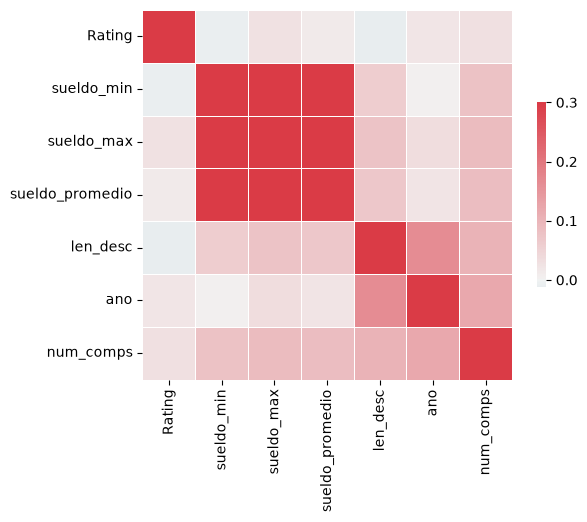

In [11]:
### Visual
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df[cuantitativa].corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Barplots para varaibles cualitativas y binarias

graph for Industry: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


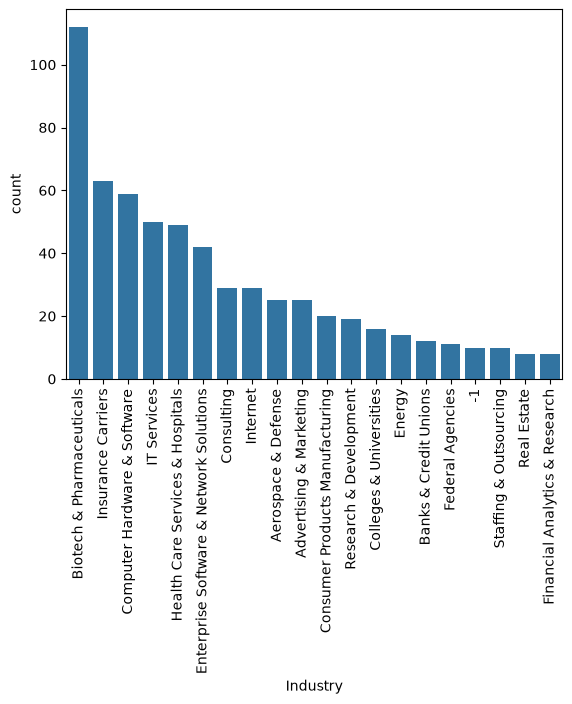

graph for Sector: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


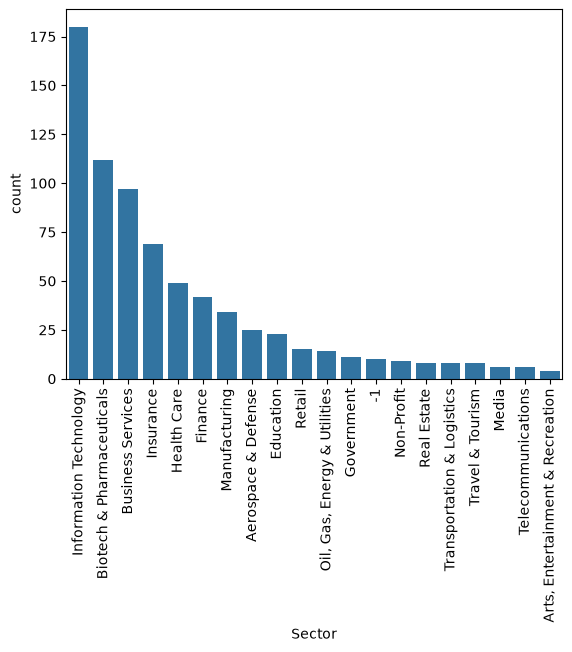

graph for Revenue: total = 14


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


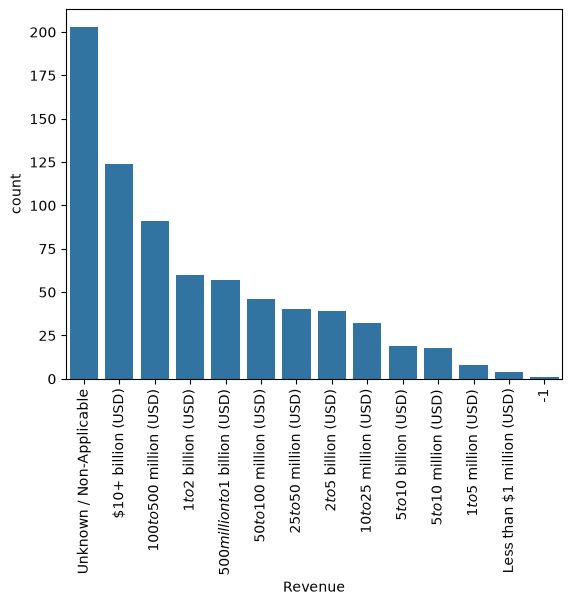

graph for titulo: total = 9


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


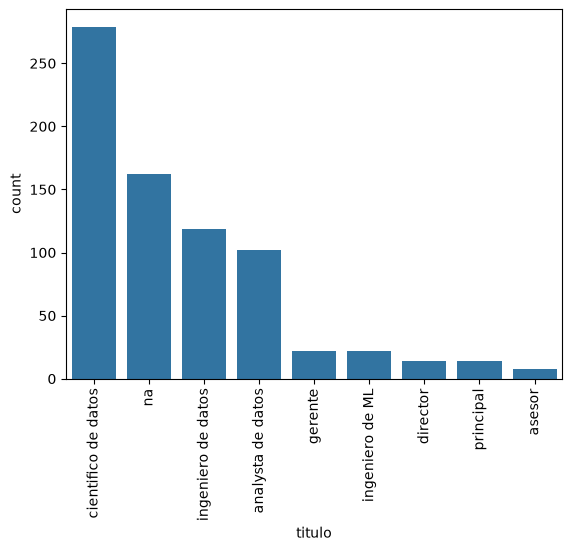

graph for senioridad: total = 3


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


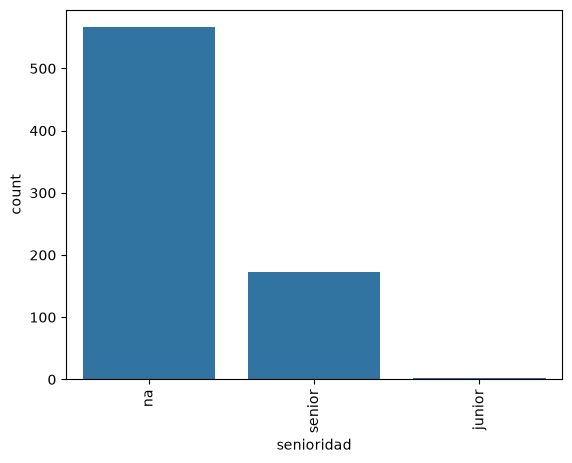

C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


graph for compania: total = 20


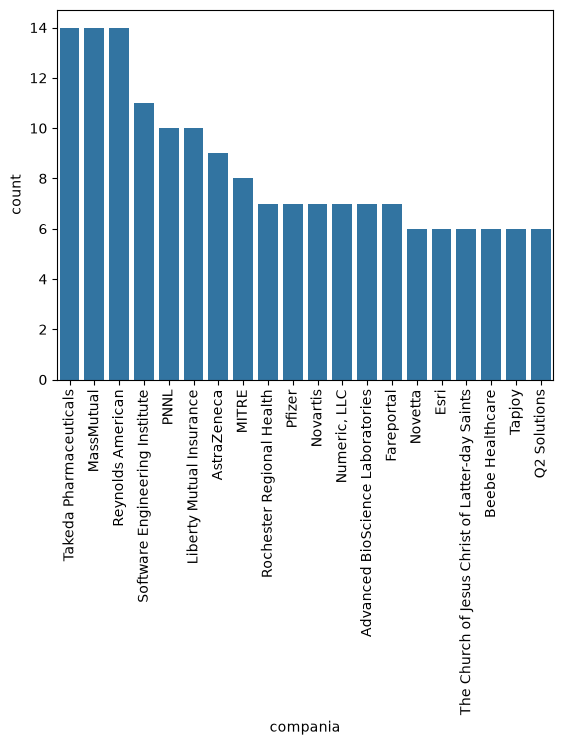

graph for estado: total = 20


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


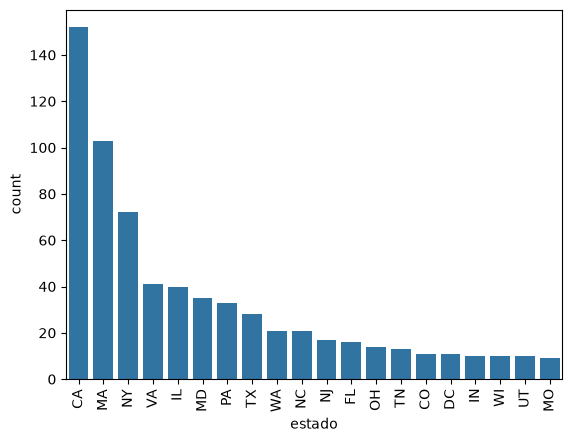

graph for tamano: total = 9


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


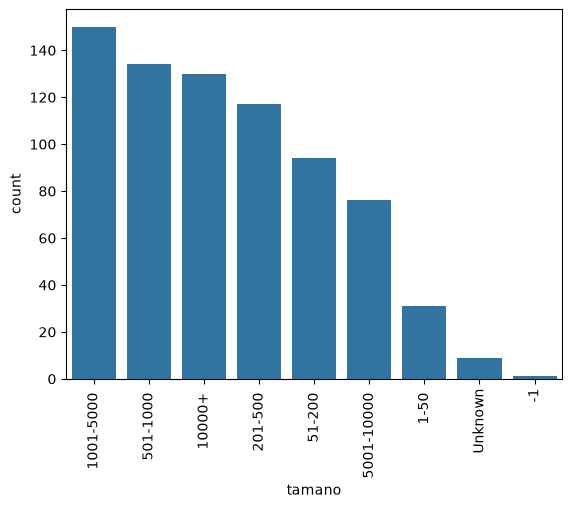

C:\Users\JP\AppData\Local\Temp\ipykernel_11112\152848988.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


graph for org: total = 9


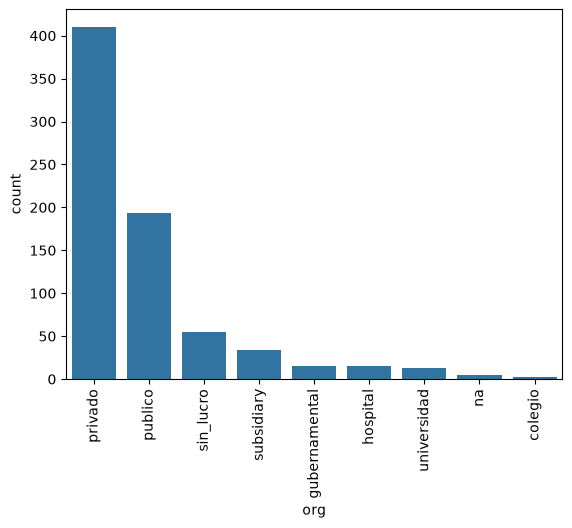

In [13]:
### 1 bargraph para cada varaible cualitativa
    # Enfoque: solo los primero 20 mejores
for i in cualitativa:
    cat_num = df[i].value_counts()[:20]
    print("graph for %s: total = %d" % (i, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

graph for cada_hora: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


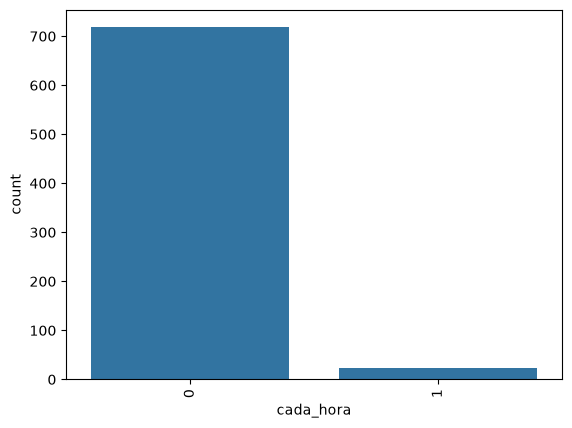

C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


graph for empleador: total = 2


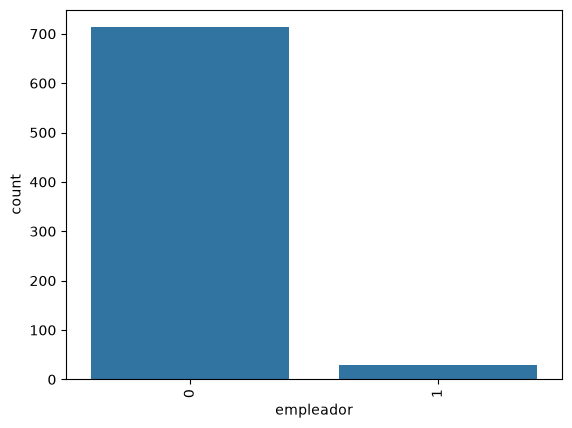

graph for python_yn: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


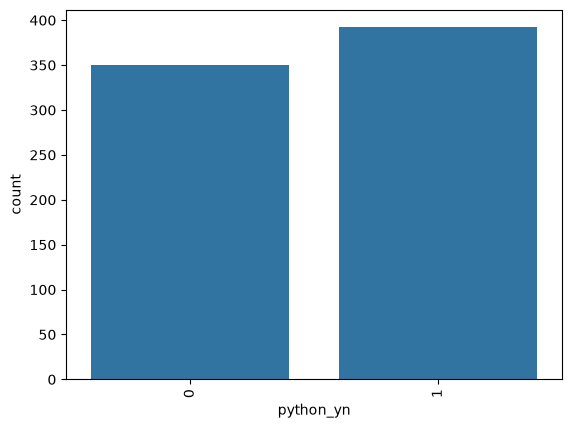

graph for r_yn: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


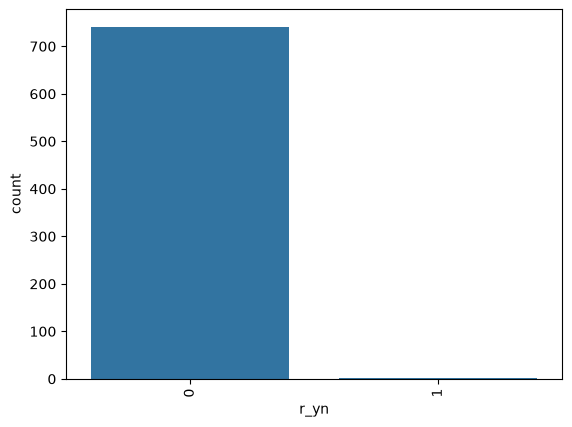

graph for spark_yn: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


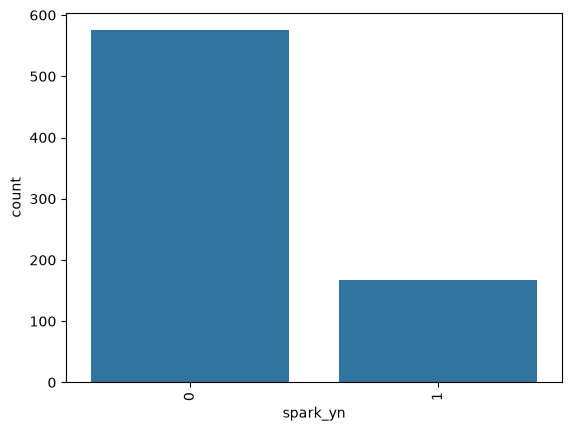

C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


graph for aws_yn: total = 2


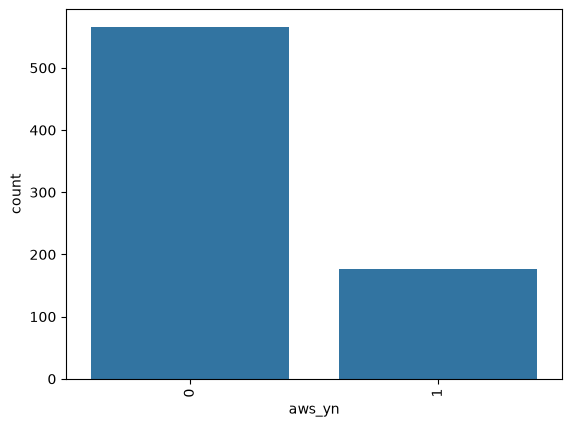

graph for excel_yn: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


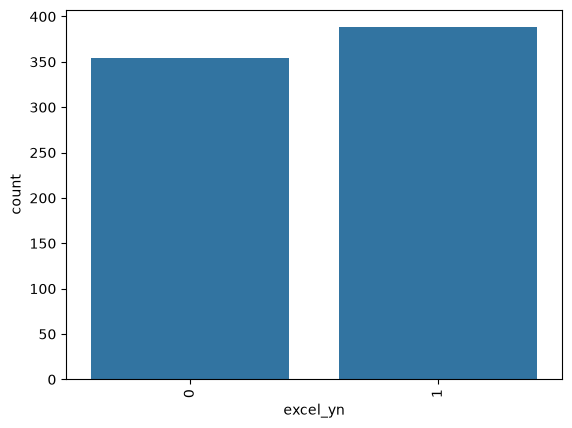

graph for HQ: total = 2


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\3938643968.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


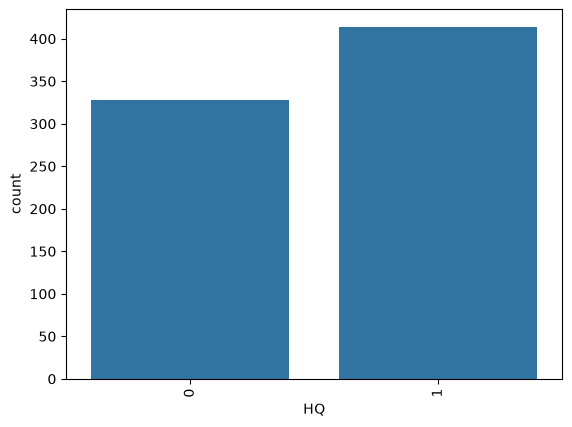

In [14]:
### 1 bargraph para cada varaible binaria
    # Enfoque: solo los primero 20 mejores
for i in binario:
    bin_num = df[i].value_counts()[:20]
    print("graph for %s: total = %d" % (i, len(bin_num)))
    chart = sns.barplot(x=bin_num.index, y=bin_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

### Creando pivot tables

In [15]:
#### Recordar variables
cualitativa= ['Industry', 'Sector', 'Revenue', 'titulo', 'senioridad', 'compania', 'estado', 'tamano', 'org']
binario= ['cada_hora', 'empleador', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'HQ' ]
cuantitativa= ['Rating', 'sueldo_min', 'sueldo_max', 'sueldo_promedio', 'len_desc', 'ano', 'num_comps']


In [16]:
pd.pivot_table(df, index = cualitativa[3], values='sueldo_promedio')

,sueldo_promedio
titulo,
analysta de datos,66.122549
asesor,69.250000
cientifico de datos,117.564516
director,168.607143
gerente,84.022727
ingeniero de ML,126.431818
ingeniero de datos,105.403361
na,87.234568
principal,107.142857


In [20]:
pd.pivot_table(df, index=cualitativa[2:4], values='sueldo_promedio')

sueldo_promedio
Revenue                  titulo                              
$1 to $2 billion (USD)   analysta de datos          80.916667
                         cientifico de datos       110.312500
                         ingeniero de datos         98.666667
                         na                        105.269231
$1 to $5 million (USD)   cientifico de datos       132.700000
...                                                       ...
Unknown / Non-Applicable gerente                   109.250000
                         ingeniero de ML           128.821429
                         ingeniero de datos         98.237500
                         na                         77.987500
                         principal                 132.500000

[73 rows x 1 columns]

In [31]:
#### Tabla de pivot para estado
pd.pivot_table(
    df,
    index = cualitativa[-3],
    values='sueldo_promedio'
).sort_values(
    'sueldo_promedio',
    ascending=False
)

,sueldo_promedio
estado,
CA,123.513158
IL,116.662500
DC,110.181818
MA,107.412621
NJ,104.558824
MI,100.250000
RI,100.000000
NY,98.652778
NC,98.452381


In [36]:
#### Tabla de pivot para estado y posicion
pd.pivot_table(
    df, 
    index=[cualitativa[i] for i in (-3, 3)],
    values='sueldo_promedio'
    ).sort_values(
        # cualitativa[-3],
        # cualitativa[3], 
        'sueldo_promedio',
        ascending=False
    )

,,sueldo_promedio
estado,titulo,
IL,director,221.75
CA,ingeniero de ML,177.30
NJ,director,161.50
DC,cientifico de datos,149.00
MA,principal,145.00
...,...,...
IA,analysta de datos,43.00
MO,gerente,40.50
LA,na,40.00


C:\Users\JP\AppData\Local\Temp\ipykernel_11112\1495018649.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  chart = sns.barplot(x=df['titulo'], y=df['sueldo_promedio'], ci=None)
C:\Users\JP\AppData\Local\Temp\ipykernel_11112\1495018649.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


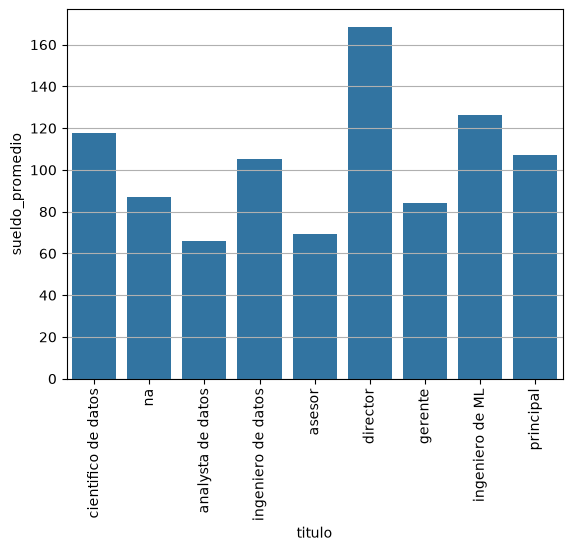

In [47]:
#### investigando el sueldo promedio entre titulos
### Pivot tabla
pd.pivot_table(
    df,
    index = cualitativa[3],
    values='sueldo_promedio'
).sort_values(
    'sueldo_promedio',
    # cualitativa[3],
    ascending=False
)

### Visualizando con sns
chart = sns.barplot(x=df['titulo'], y=df['sueldo_promedio'], ci=None)
    #"ci" = elimnar error bars
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
chart.grid(True, axis='y')
plt.show()

In [48]:
#### Viendo pivot tabla para ciencas de datos por estado
pd.pivot_table(
    df[df['titulo'] == 'cientifico de datos'],
    index = 'estado',
    values='sueldo_promedio',
).sort_values(
    'sueldo_promedio',
    ascending=False
)

,sueldo_promedio
estado,
DC,149.000000
CA,142.522059
UT,140.500000
MO,127.666667
IL,117.233333
NC,117.000000
NY,115.250000
MA,113.750000
WI,113.500000


In [77]:
#### Creando varios pivot tablas a la misma vez
df_pivots = df[cualitativa[1:4] + ['sueldo_promedio']]
# display(df_pivots)
# pd.pivot_table(
#     df_pivots,
#     index = 'Sector',
#     values = 'sueldo_promedio',
#     # aggfunc='count'
# ).sort_values(
#     'sueldo_promedio',
#     ascending=False
# )
for i in df_pivots.columns.to_list()[:-1]:
    print(i)
    print(pd.pivot_table(
        df_pivots,
        index = i,
        values = 'sueldo_promedio',
        # aggfunc='count'
    ).sort_values(
        'sueldo_promedio',
        ascending=False
    ))
    print('\n\n')

Sector
                                    sueldo_promedio
Sector                                             
Media                                    116.666667
-1                                       114.650000
Accounting & Legal                       113.500000
Information Technology                   113.191667
Biotech & Pharmaceuticals                112.098214
Insurance                                105.942029
Real Estate                              104.750000
Mining & Metals                          104.000000
Telecommunications                       102.333333
Education                                100.739130
Consumer Services                         99.875000
Retail                                    99.666667
Transportation & Logistics                99.312500
Aerospace & Defense                       99.060000
Finance                                   98.011905
Business Services                         97.701031
Manufacturing                             84.044118
Agric

### Pivot tablas con multipl niveles

In [83]:
pd.pivot_table(
    df,
    index='Rating',
    columns='titulo',    # Esta linea crea nuevo niveles
    values='sueldo_promedio',
    # aggfunc='count'
).sort_values(
    'Rating',
    ascending=False
)

titulo,analysta de datos,asesor,cientifico de datos,director,gerente,ingeniero de ML,ingeniero de datos,na,principal
Rating,,,,,,,,,
5.0,NaN,NaN,135.250000,NaN,NaN,NaN,132.500000,NaN,NaN
4.8,61.000000,NaN,104.000000,NaN,61.500000,NaN,NaN,NaN,NaN
4.7,57.750000,114.5,117.750000,NaN,NaN,232.5,112.200000,72.666667,NaN
4.6,51.333333,NaN,113.625000,NaN,NaN,NaN,75.500000,121.000000,167.5
4.5,121.500000,NaN,143.500000,NaN,NaN,NaN,122.500000,48.000000,NaN
4.4,53.500000,66.5,122.714286,140.000000,NaN,NaN,96.437500,99.214286,NaN
4.3,74.600000,NaN,117.382353,NaN,87.500000,100.5,104.375000,72.500000,NaN
4.2,72.250000,52.5,127.166667,NaN,221.500000,NaN,87.857143,NaN,NaN
4.1,64.500000,NaN,115.000000,NaN,NaN,111.0,161.400000,NaN,NaN


### Word Cloud

In [84]:
#### Importaciones
from wordcloud import WordCloud, ImageColorGenerator, STOPWORDS
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

ModuleNotFoundError: No module named 'wordcloud'

In [85]:
words = " ".join(df['Job Description'])

def punctuation_stop(text):
    """remove punctuation and stop words"""
    filtered = []
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    for w in word_tokens:
        if w not in stop_words and w.isalpha():
            filtered.append(w.lower())
    return filtered


words_filtered = punctuation_stop(words)

text = " ".join([ele for ele in words_filtered])

wc= WordCloud(background_color="white", random_state=1,stopwords=STOPWORDS, max_words = 2000, width =800, height = 1500)
wc.generate(text)

plt.figure(figsize=[10,10])
plt.imshow(interpolation="bilinear")
plt.axis('off')
plt.show()

KeyError: 'Job Description'